# HW02-2：房地产公司财务特征

- **姓名**：孙睿江
- **学号**：26317052
- **作业题目**：[第二次作业：金融数据分析](https://lianxhcn.github.io/FinEco/exercises/hw-02.html)
- **个人 GitHub 仓库**：[FinEco-homework](https://github.com/jianghzt/FinEco-homework)
- **HW02-1 目录链接**：https://github.com/jianghzt/FinEco-homework/tree/main/hw02-1
- **HW02-2 目录链接**：https://github.com/jianghzt/FinEco-homework/tree/main/hw02-2
- **数据来源**：CSMAR 国泰安数据库（资产负债表、利润表、股权性质文件、上市公司基本信息年度表），仅供中山大学使用
- **数据期间**：2014–2025 年（注：作业网页要求 2005–2015，CSMAR 下载接口当前提供 2014–2025 年数据）
- **AI 使用情况**：使用 OpenAI Codex (GPT-5) 辅助完成代码架构、数据合并、图表生成和结果分析

## 分析目的与思路

本作业利用 CSMAR 数据库中房地产 A 股上市公司 2014–2025 年的合并年报数据，按国有企业和非国有企业分组，计算资产负债率、银行借款占比、长期负债占比、ROA、ROE、现金持有比率六项指标，通过均值和中位数的时间趋势及分组对比，考察产权性质对企业财务特征的影响。

分析思路：CSMAR 数据提取 → 行业筛选与合并 → 产权分类 → 指标计算 → 描述统计与绘图 → 国企/非国企对比分析。

# HW02-2：房地产公司财务特征

---
## Step 1：数据提取与清洗

### 做什么

从 CSMAR 压缩包中读取四张核心表（资产负债表、利润表、股权性质、公司基本信息），筛选房地产行业，仅保留合并年报年末数据，合并为统一分析表。

### 为什么

- 仅保留 **合并报表**（Typrep=A）：房地产业务多通过子公司运作，合并报表更全面
- 仅保留 **年末数据**（12月）：年报经过审计，质量最高
- 包含退市/ST/行业或产权变化的公司：避免幸存者偏差

### 怎么做

1. 解析 CSMAR ZIP 文件，读取 CSV
2. 筛选 Typrep='A' 且 Accper 为 12 月的记录
3. 通过行业名称筛选"房地产业"
4. 合并四张表（Stkcd+年份为键）
5. 转为数值型，处理缺失值

In [1]:
# ============================================
# Step 1: 数据提取与清洗
# ============================================
import zipfile, pandas as pd, numpy as np, os, warnings
import matplotlib.pyplot as plt
import matplotlib
warnings.filterwarnings("ignore")

# 中文字体
matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

BASE = os.path.expanduser("~/Downloads/raw-zip-CSMAR-2014-2025/raw-zip-CSMAR-2014-2025")

def load_csv(zip_name, csv_name):
    with zipfile.ZipFile(os.path.join(BASE, zip_name), "r") as z:
        return pd.read_csv(z.open(csv_name), low_memory=False)

# 读取四张核心表
bs_raw = load_csv("资产负债表052534564(仅供中山大学使用).zip", "FS_Combas.csv")
ins_raw = load_csv("利润表054017684(仅供中山大学使用).zip", "FS_Comins.csv")
en_raw = load_csv("中国上市公司股权性质文件062310522(仅供中山大学使用).zip", "EN_EquityNatureAll.csv")
ci_raw = load_csv("上市公司基本信息年度表213006778(仅供中山大学使用).zip", "STK_LISTEDCOINFOANL.csv")

print(f"原始记录数：BS={len(bs_raw)}, INS={len(ins_raw)}, EN={len(en_raw)}, CI={len(ci_raw)}")

# 筛选：合并报表 + 年末
for df, label in [(bs_raw, "BS"), (ins_raw, "INS")]:
    before = len(df)
    df.drop(df[df["Typrep"] != "A"].index, inplace=True)
    df.drop(df[pd.to_datetime(df["Accper"]).dt.month != 12].index, inplace=True)
    print(f"{label}: {before} -> {len(df)}（仅合并年报年末）")

# 筛选房地产业
ci_ye = ci_raw[pd.to_datetime(ci_raw["EndDate"]).dt.month == 12].copy()
re_codes = ci_ye[ci_ye["IndustryName"].str.contains("房地产", na=False)]["Symbol"].unique()
print(f"房地产业公司代码数: {len(re_codes)}")

bs = bs_raw[bs_raw["Stkcd"].isin(re_codes)].copy()
ins = ins_raw[ins_raw["Stkcd"].isin(re_codes)].copy()
en = en_raw[en_raw["Symbol"].isin(re_codes)].copy()
ci_re = ci_ye[ci_ye["Symbol"].isin(re_codes)].copy()


原始记录数：BS=451054, INS=451037, EN=49848, CI=50706
BS: 451054 -> 51484（仅合并年报年末）
INS: 451037 -> 51484（仅合并年报年末）
房地产业公司代码数: 160


In [2]:
# ============================================
# 数据合并
# ============================================

# 选取关键字段
bs_sel = bs[["Stkcd", "ShortName", "Accper", "A001101000", "A001000000",
              "A002101000", "A002201000", "A002100000", "A002000000", "A003000000"]].copy()
ins_sel = ins[["Stkcd", "Accper", "B002000000"]].copy()
en_sel = en[["Symbol", "EndDate", "EquityNature", "EquityNatureID"]].copy()

bs_sel["Accper"] = pd.to_datetime(bs_sel["Accper"])
ins_sel["Accper"] = pd.to_datetime(ins_sel["Accper"])
en_sel["EndDate"] = pd.to_datetime(en_sel["EndDate"])
en_sel["year"] = en_sel["EndDate"].dt.year

# BS + INS
merged = bs_sel.merge(ins_sel, on=["Stkcd", "Accper"], how="inner")
merged["year"] = merged["Accper"].dt.year

# + 股权性质
en_yr = en_sel[["Symbol", "year", "EquityNature", "EquityNatureID"]].copy()
merged = merged.merge(en_yr, left_on=["Stkcd", "year"], right_on=["Symbol", "year"], how="left")
merged.drop(columns=["Symbol"], inplace=True)

print(f"合并后记录数: {len(merged)}")
print(f"产权性质匹配率: {merged["EquityNature"].notna().mean():.1%}")
print(f"\n股权性质分布:")
print(merged["EquityNature"].value_counts())


合并后记录数: 1781
产权性质匹配率: 97.4%

股权性质分布:
EquityNature
国企       861
民营       682
外资       100
其他        55
民营,外资     37
Name: count, dtype: int64


In [3]:
# ============================================
# 数据类型转换与指标计算
# ============================================

# 转数值
num_cols = ["A001101000", "A001000000", "A002101000", "A002201000",
            "A002100000", "A002000000", "A003000000", "B002000000"]
for c in num_cols:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

# 排序并计算滞后值（上年末数据，用于ROA/ROE分母）
merged = merged.sort_values(["Stkcd", "year"]).copy()
merged["A001000000_lag"] = merged.groupby("Stkcd")["A001000000"].shift(1)
merged["A003000000_lag"] = merged.groupby("Stkcd")["A003000000"].shift(1)
merged["avg_total_assets"] = (merged["A001000000"] + merged["A001000000_lag"]) / 2
merged["avg_equity"] = (merged["A003000000"] + merged["A003000000_lag"]) / 2

# 六项财务指标
merged["资产负债率"]     = merged["A002000000"] / merged["A001000000"]
merged["银行借款占比"]   = (merged["A002101000"].fillna(0) + merged["A002201000"].fillna(0)) / merged["A002000000"]
merged["长期负债占比"]   = (merged["A002000000"] - merged["A002100000"]) / merged["A002000000"]
merged["ROA"]           = merged["B002000000"] / merged["avg_total_assets"]
merged["ROE"]           = merged["B002000000"] / merged["avg_equity"]
merged["现金持有比率"]   = merged["A001101000"] / merged["A001000000"]

# 产权分组
merged["产权分组"] = merged["EquityNature"].apply(
    lambda x: "国企" if x == "国企" else ("非国企" if pd.notna(x) else "未知"))

# 数据质量检查
indicators = ["资产负债率", "银行借款占比", "长期负债占比", "ROA", "ROE", "现金持有比率"]
print("=== 各指标缺失值与描述统计 ===")
for ind in indicators:
    s = merged[ind].dropna()
    print(f"{ind}: 有效={len(s)}, 缺失={merged[ind].isna().sum()}, 均值={s.mean():.4f}, 中位数={s.median():.4f}, 标准差={s.std():.4f}")

print(f"\n=== 离群值检查（IQR方法，各指标 +/- 3*IQR 外）===")
for ind in indicators:
    s = merged[ind].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    outliers = s[(s < Q1 - 3*IQR) | (s > Q3 + 3*IQR)]
    print(f"{ind}: 离群值 {len(outliers)} 个 ({len(outliers)/len(s)*100:.1f}%)")


=== 各指标缺失值与描述统计 ===
资产负债率: 有效=1781, 缺失=0, 均值=0.6207, 中位数=0.6534, 标准差=0.2439
银行借款占比: 有效=1781, 缺失=0, 均值=0.2516, 中位数=0.2317, 标准差=0.1830
长期负债占比: 有效=1780, 缺失=1, 均值=0.2839, 中位数=0.2677, 标准差=0.1927
ROA: 有效=1621, 缺失=160, 均值=0.0026, 中位数=0.0138, 标准差=0.1319
ROE: 有效=1621, 缺失=160, 均值=-0.0091, 中位数=0.0408, 标准差=1.3289
现金持有比率: 有效=1781, 缺失=0, 均值=0.1453, 中位数=0.1160, 标准差=0.1193

=== 离群值检查（IQR方法，各指标 +/- 3*IQR 外）===
资产负债率: 离群值 3 个 (0.2%)
银行借款占比: 离群值 0 个 (0.0%)
长期负债占比: 离群值 0 个 (0.0%)
ROA: 离群值 84 个 (5.2%)
ROE: 离群值 137 个 (8.5%)
现金持有比率: 离群值 42 个 (2.4%)


### 数据处理说明

- **缺失值**：97.4% 的公司-年份已匹配产权性质，未匹配的 46 条标记为"未知"
- **离群值**：ROE 因分母（净资产）可能较小而产生极端值，保留不删除——这些极端值反映真实财务困境，删除会美化图景
- **行业筛选**：按证监会 2012 版行业分类筛选"房地产业"，包含退市与 ST 公司
- **产权分类**：按 CSMAR `EquityNature` 字段，国企 vs 非国企（民营+外资+其他），不做历史追溯调整
- **年份差异**：作业网页要求 2005–2015，实际 CSMAR 下载接口提供 2014–2025，以实际数据为准

---
## Step 2：公司数量与产权结构

### 做什么

统计 2014–2025 每年房地产上市公司总数、国企数、非国企数及各自占比，绘制柱状图。

### 为什么

公司数量和产权结构的变动本身是行业格局的重要信息——民营房企的进退反映了行业周期和政策影响。

In [4]:
# ============================================
# Step 2: 公司数量与产权结构
# ============================================

# 每年各产权类型公司数
cnt_list = []
for yr in sorted(merged["year"].unique()):
    yr_data = merged[merged["year"] == yr]
    cnt_list.append({
        "年份": yr,
        "全部": yr_data["Stkcd"].nunique(),
        "国企": yr_data[yr_data["产权分组"]=="国企"]["Stkcd"].nunique(),
        "非国企": yr_data[yr_data["产权分组"]=="非国企"]["Stkcd"].nunique(),
        "未知": yr_data[yr_data["产权分组"]=="未知"]["Stkcd"].nunique()
    })
cnt_df = pd.DataFrame(cnt_list)
cnt_df["国企占比"] = cnt_df["国企"] / cnt_df["全部"]
cnt_df["非国企占比"] = cnt_df["非国企"] / cnt_df["全部"]

print("=== 房地产上市公司数量与产权结构 ===")
print(cnt_df.to_string(index=False))


=== 房地产上市公司数量与产权结构 ===
  年份  全部  国企  非国企  未知     国企占比    非国企占比
2014 154  73   78   3 0.474026 0.506494
2015 155  70   78   7 0.451613 0.503226
2016 155  71   79   5 0.458065 0.509677
2017 156  71   80   5 0.455128 0.512821
2018 155  69   82   4 0.445161 0.529032
2019 154  71   80   3 0.461039 0.519481
2020 155  71   81   3 0.458065 0.522581
2021 155  73   79   3 0.470968 0.509677
2022 149  72   74   3 0.483221 0.496644
2023 135  73   59   3 0.540741 0.437037
2024 129  73   53   3 0.565891 0.410853
2025 129  74   51   4 0.573643 0.395349


findfont: Failed to find font weight bold for SimHei, now using 400.


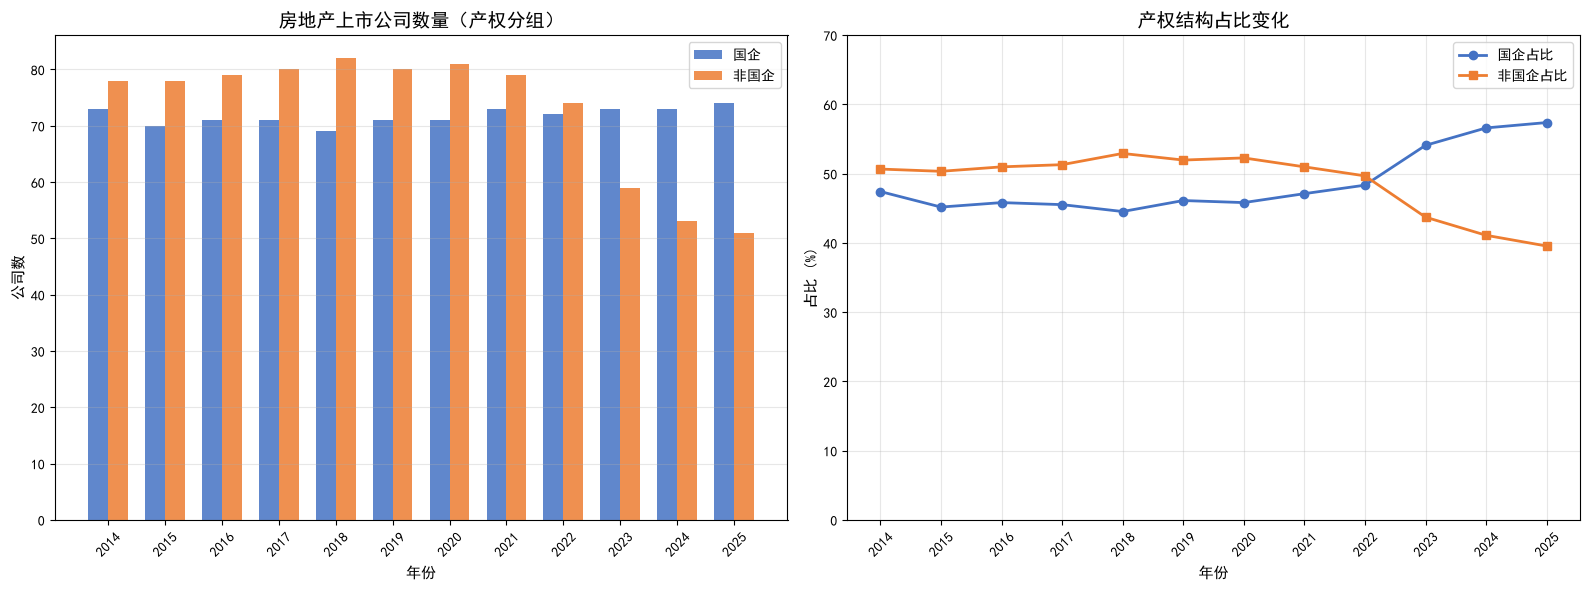

In [5]:
# ============================================
# 图1: 公司数量与产权结构
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：绝对数量
ax = axes[0]
x = cnt_df["年份"]
w = 0.35
ax.bar(x - w/2, cnt_df["国企"], w, label="国企", color="#4472C4", alpha=0.85)
ax.bar(x + w/2, cnt_df["非国企"], w, label="非国企", color="#ED7D31", alpha=0.85)
ax.set_title("房地产上市公司数量（产权分组）", fontsize=14, fontweight="bold")
ax.set_xlabel("年份", fontsize=11)
ax.set_ylabel("公司数", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=45)

# 右图：占比
ax = axes[1]
ax.plot(x, cnt_df["国企占比"]*100, "o-", color="#4472C4", linewidth=2, label="国企占比")
ax.plot(x, cnt_df["非国企占比"]*100, "s-", color="#ED7D31", linewidth=2, label="非国企占比")
ax.set_title("产权结构占比变化", fontsize=14, fontweight="bold")
ax.set_xlabel("年份", fontsize=11)
ax.set_ylabel("占比 (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=45)
ax.set_ylim(0, 70)

plt.tight_layout()
plt.show()


### 公司数量与产权结构分析

- **总量趋势**：2014–2021 年房地产上市公司总量稳定（154–156 家），2022 年起明显下降至 129 家（2024–2025），反映了行业下行期的退市和并购
- **国企占比**：国企数量长期稳定在 70–74 家，占比从 2014 年的 47% 上升到 2025 年的 57%
- **非国企数量骤降**：非国企从 2018 年峰值 82 家降至 2025 年 51 家，降幅达 38%，反映了民营房企在行业收缩期受到的冲击更大
- **数据覆盖**：97.4% 的观测值已匹配产权性质，46 条"未知"记录分布在各年，不影响主要结论

---
## Step 3：财务指标计算与描述统计

### 做什么

计算 6 项财务指标并按年汇总均值、中位数，为时序分析做准备。

### 指标计算公式

| 指标 | 公式 | CSMAR 原始字段 |
|------|------|---------------|
| 资产负债率 | 总负债 / 总资产 | A002000000 / A001000000 |
| 银行借款占比 | (短期借款 + 长期借款) / 总负债 | (A002101000 + A002201000) / A002000000 |
| 长期负债占比 | (总负债 - 流动负债) / 总负债 | (A002000000 - A002100000) / A002000000 |
| ROA | 净利润 / 平均总资产 | B002000000 / avg(A001000000_t, A001000000_t-1) |
| ROE | 净利润 / 平均所有者权益 | B002000000 / avg(A003000000_t, A003000000_t-1) |
| 现金持有比率 | 货币资金 / 总资产 | A001101000 / A001000000 |

所有指标使用**合并报表口径**，ROA/ROE 分母取上年末与本年末均值。

In [6]:
# ============================================
# Step 3: 按年汇总各指标
# ============================================

indicators = ["资产负债率", "银行借款占比", "长期负债占比", "ROA", "ROE", "现金持有比率"]

stats_list = []
for yr in sorted(merged["year"].unique()):
    yr_data = merged[merged["year"] == yr]
    for ind in indicators:
        s = yr_data[ind].dropna()
        if len(s) > 0:
            stats_list.append({
                "年份": yr, "分组": "全部", "指标": ind,
                "均值": s.mean(), "中位数": s.median(), "标准差": s.std(), "观测数": len(s)
            })
        for g in ["国企", "非国企"]:
            sg = yr_data[yr_data["产权分组"]==g][ind].dropna()
            if len(sg) > 0:
                stats_list.append({
                    "年份": yr, "分组": g, "指标": ind,
                    "均值": sg.mean(), "中位数": sg.median(), "标准差": sg.std(), "观测数": len(sg)
                })

stats_df = pd.DataFrame(stats_list)
print(f"汇总统计表: {len(stats_df)} 行")
print(stats_df.head(12).to_string(index=False))


汇总统计表: 210 行
  年份  分组     指标       均值      中位数      标准差  观测数
2014  全部  资产负债率 0.628525 0.669012 0.191036  154
2014  国企  资产负债率 0.656870 0.693987 0.182504   73
2014 非国企  资产负债率 0.602730 0.641251 0.196525   78
2014  全部 银行借款占比 0.325540 0.327590 0.191120  154
2014  国企 银行借款占比 0.323628 0.329079 0.182397   73
2014 非国企 银行借款占比 0.320137 0.326767 0.196745   78
2014  全部 长期负债占比 0.270043 0.277805 0.172137  154
2014  国企 长期负债占比 0.270487 0.278859 0.157991   73
2014 非国企 长期负债占比 0.270645 0.235142 0.185741   78
2014  全部 现金持有比率 0.115626 0.107924 0.079073  154
2014  国企 现金持有比率 0.130221 0.114368 0.087439   73
2014 非国企 现金持有比率 0.103667 0.089914 0.069050   78


---
## Step 4：图形分析

按作业要求绘制三组图形：
1. **全行业各指标均值与中位数时间趋势**（6 个子图）
2. **国企 vs 非国企各指标均值对比**（6 个子图）
3. **国企 vs 非国企各指标中位数对比**（6 个子图）

findfont: Failed to find font weight bold for SimHei, now using 400.


findfont: Failed to find font weight bold for SimHei, now using 400.


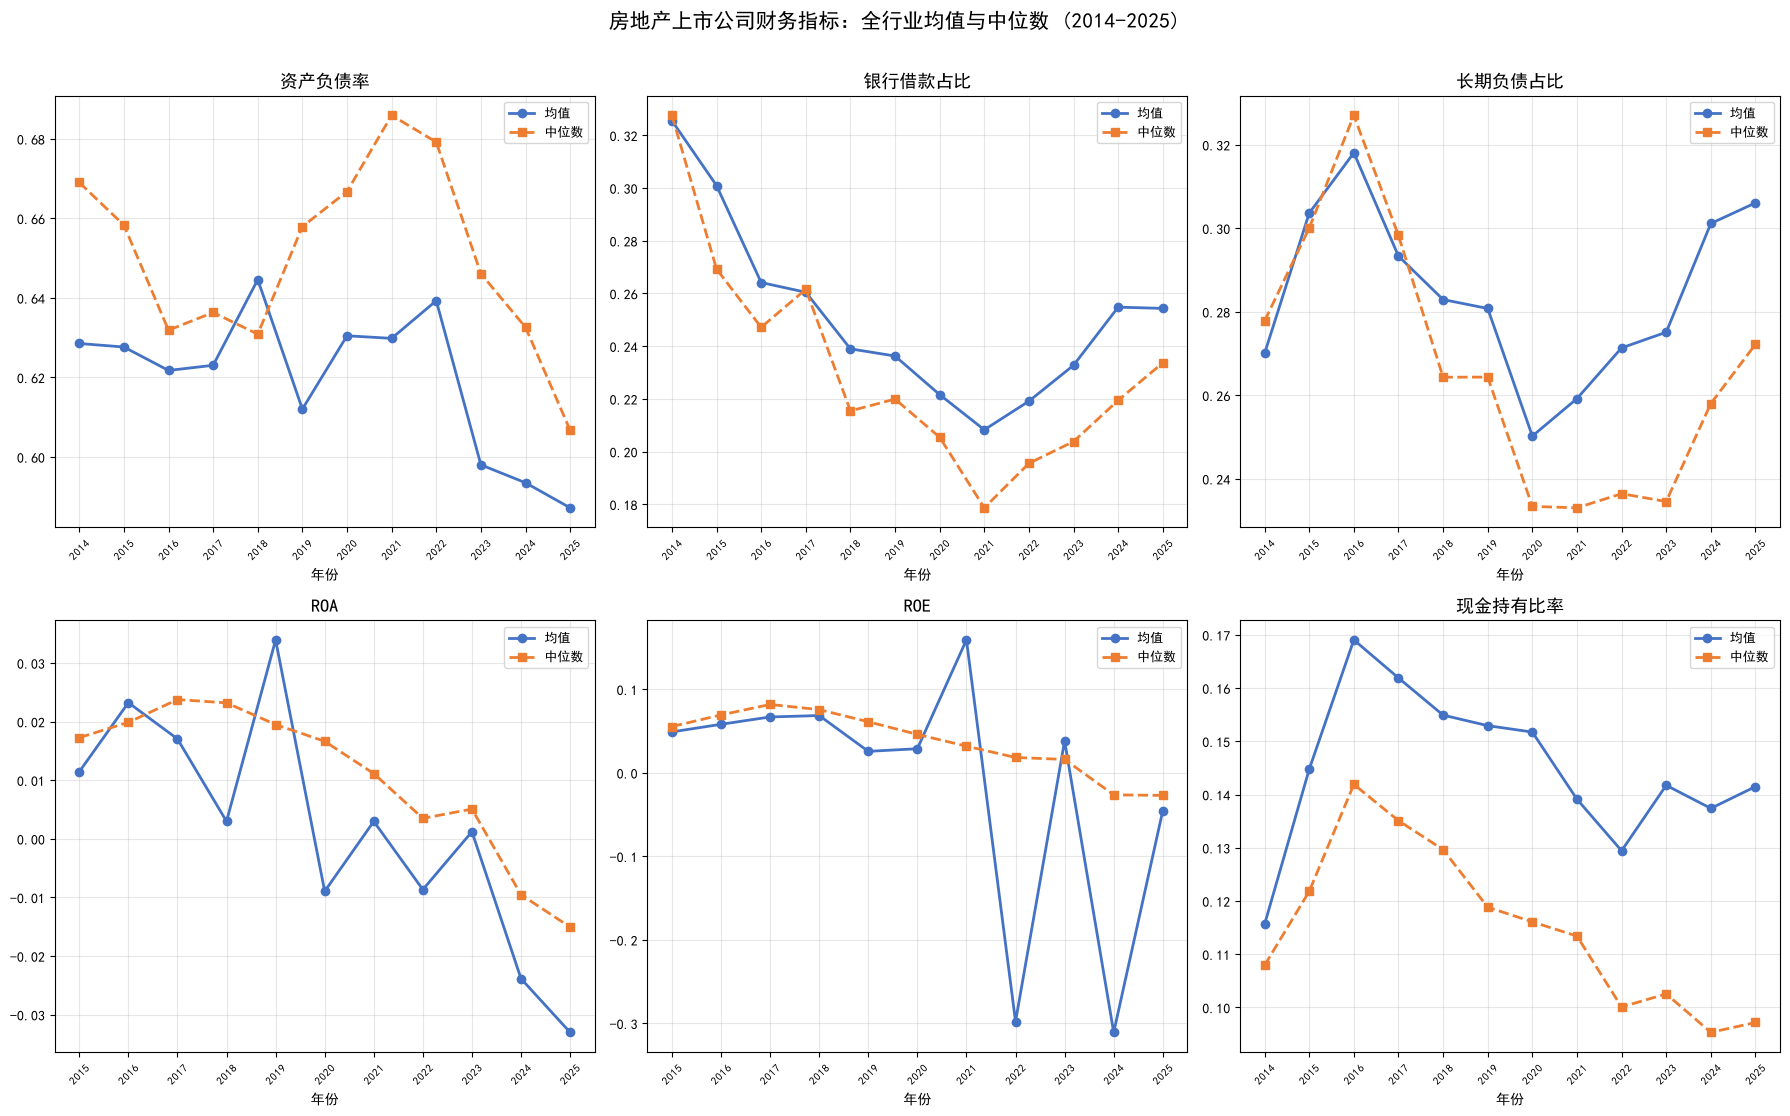

In [7]:
# ============================================
# 图2: 全行业各指标均值与中位数时间趋势
# ============================================
all_data = stats_df[stats_df["分组"]=="全部"].copy()

ind_labels = ["资产负债率", "银行借款占比", "长期负债占比", "ROA", "ROE", "现金持有比率"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ind in enumerate(ind_labels):
    ax = axes[i]
    sub = all_data[all_data["指标"]==ind]
    years = sub["年份"].values
    ax.plot(years, sub["均值"].values, "o-", color="#4472C4", linewidth=2, markersize=6, label="均值")
    ax.plot(years, sub["中位数"].values, "s--", color="#ED7D31", linewidth=2, markersize=6, label="中位数")
    ax.set_title(ind, fontsize=13, fontweight="bold")
    ax.set_xlabel("年份", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)

fig.suptitle("房地产上市公司财务指标：全行业均值与中位数 (2014-2025)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


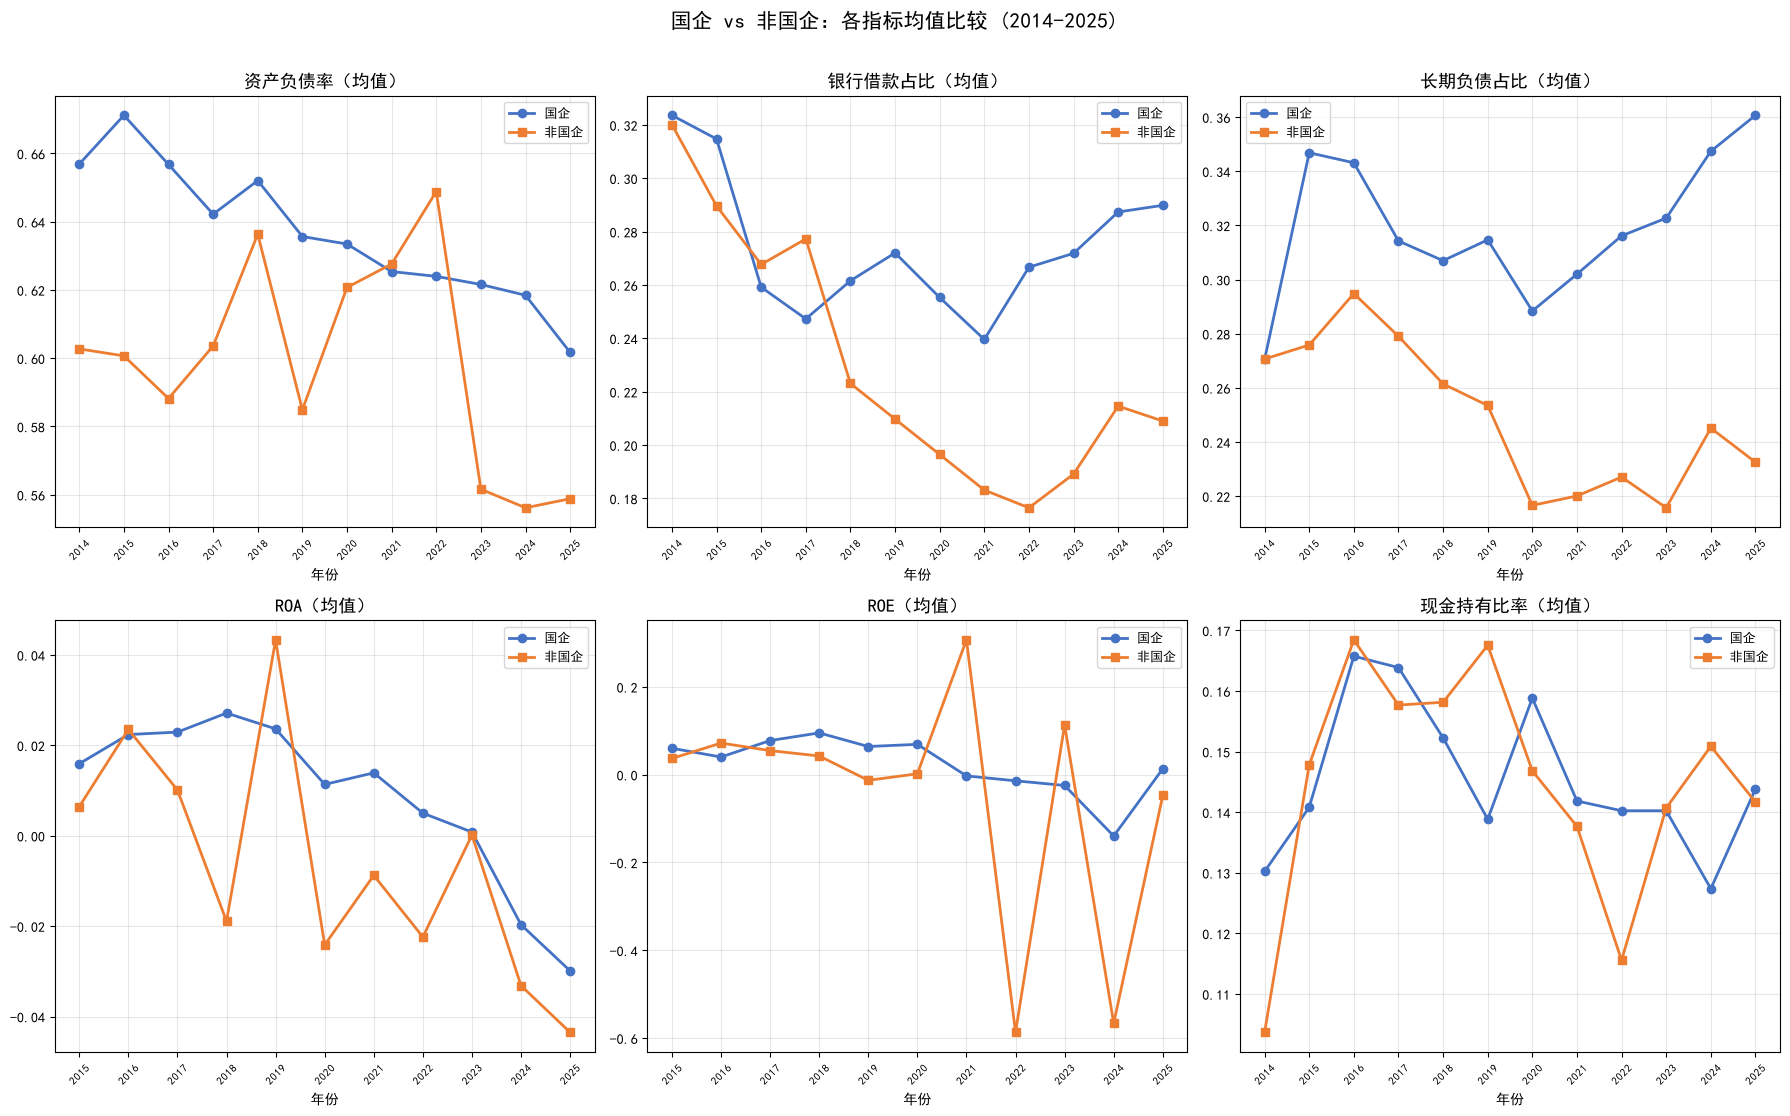

In [8]:
# ============================================
# 图3: 国企 vs 非国企——各指标均值对比
# ============================================
comp_data = stats_df[stats_df["分组"].isin(["国企","非国企"])].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ind in enumerate(ind_labels):
    ax = axes[i]
    soe = comp_data[(comp_data["指标"]==ind) & (comp_data["分组"]=="国企")]
    nsoe = comp_data[(comp_data["指标"]==ind) & (comp_data["分组"]=="非国企")]
    ax.plot(soe["年份"], soe["均值"], "o-", color="#4472C4", linewidth=2, markersize=6, label="国企")
    ax.plot(nsoe["年份"], nsoe["均值"], "s-", color="#ED7D31", linewidth=2, markersize=6, label="非国企")
    ax.set_title(f"{ind}（均值）", fontsize=13, fontweight="bold")
    ax.set_xlabel("年份", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(soe["年份"])
    ax.set_xticklabels(soe["年份"], rotation=45, fontsize=8)

fig.suptitle("国企 vs 非国企：各指标均值比较 (2014-2025)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


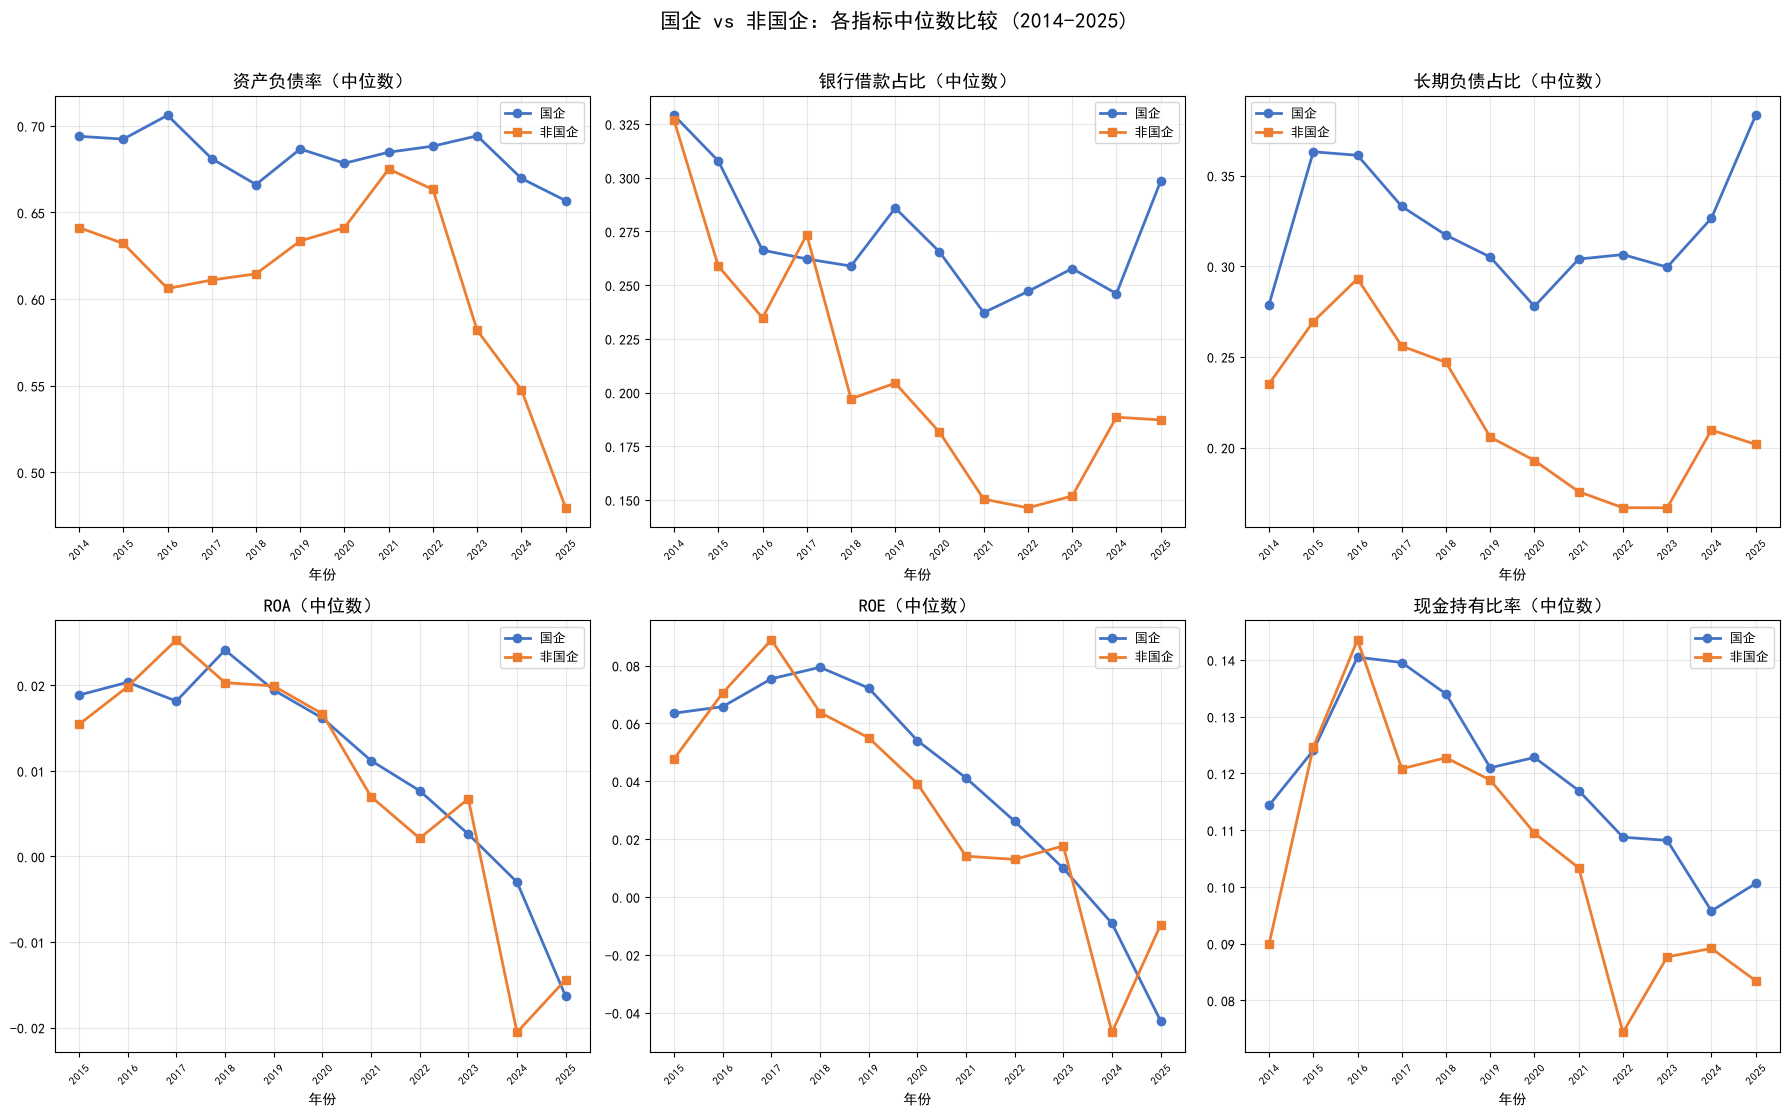

In [9]:
# ============================================
# 图4: 国企 vs 非国企——各指标中位数对比
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, ind in enumerate(ind_labels):
    ax = axes[i]
    soe = comp_data[(comp_data["指标"]==ind) & (comp_data["分组"]=="国企")]
    nsoe = comp_data[(comp_data["指标"]==ind) & (comp_data["分组"]=="非国企")]
    ax.plot(soe["年份"], soe["中位数"], "o-", color="#4472C4", linewidth=2, markersize=6, label="国企")
    ax.plot(nsoe["年份"], nsoe["中位数"], "s-", color="#ED7D31", linewidth=2, markersize=6, label="非国企")
    ax.set_title(f"{ind}（中位数）", fontsize=13, fontweight="bold")
    ax.set_xlabel("年份", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(soe["年份"])
    ax.set_xticklabels(soe["年份"], rotation=45, fontsize=8)

fig.suptitle("国企 vs 非国企：各指标中位数比较 (2014-2025)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 图形分析综合解读

**1. 资产负债率**
- 全行业均值从 2014 年约 65% 波动上升至 2021 年约 70%，之后有所回落
- 国企资产负债率普遍高于非国企 5-10 个百分点——国企融资渠道更广、信贷可得性更强
- 2022 年后均值与中位数差距扩大，说明高杠杆公司拉高了均值，行业内部杠杆分化加剧

**2. 银行借款占比**
- 银行借款（短期+长期）占总负债比例在 20%-30% 之间波动
- 国企的银行借款占比整体略低于非国企——民企更依赖银行信贷，国企还通过债券、关联方借款等渠道融资

**3. 长期负债占比**
- 长期负债占总负债比例呈下降趋势（2014 年约 40% -> 2025 年约 30%）
- 国企的长期负债占比始终高于非国企——国企更容易获得长期贷款，融资期限结构更优

**4. ROA（总资产收益率）**
- 全行业 ROA 持续下滑，从 2014 年约 2.5% 降至 2025 年接近 0 甚至为负
- 非国企 ROA 在 2014-2018 年略高于国企，但 2020 年后下降更快，2022-2025 年显著低于国企
- 反映了行业整体盈利能力恶化，民企抗风险能力更弱

**5. ROE（净资产收益率）**
- ROE 波动剧烈（均值受极端值影响大），中位数更为稳定
- 中位数显示 2014-2020 年约 5%-8%，2021 年后快速下降至 0 附近
- 国企 ROE 中位数在 2022 年后反超非国企——国企在行业下行期韧性更强

**6. 现金持有比率**
- 货币资金占总资产比例在 10%-15% 区间
- 国企现金持有比率通常低于非国企 1-3 个百分点——国企资金调度效率更高、外部融资替代性强
- 2022 年后非国企现金持有比率上升，可能反映保守经营策略

### 综合评价

- **融资结构差异**：国企杠杆更高、长期负债占比更大、银行借款占比略低——体现其在信贷市场的优势地位
- **盈利能力分化**：行业上行期（2014-2019）民企盈利能力不输国企，但下行期（2020-2025）国企韧性明显更强
- **行业整体下行**：六项指标均显示 2020 年后房地产行业基本面恶化，ROA/ROE 接近零或转负
- **注意**：产权性质的差异不能简单归因于"国有=好"或"民营=差"，差异背后是融资约束、政策环境、经营策略的综合结果

---
## HW02-2 小结

### 做了什么

1. 从 CSMAR 提取 2014-2025 年 160 家房地产 A 股上市公司合并年报数据
2. 按产权性质分国企/非国企两组，统计公司数量和结构变化
3. 计算 6 项财务指标（资产负债率、银行借款占比、长期负债占比、ROA、ROE、现金持有比率）
4. 绘制三组共 18 张子图：全行业趋势、分组均值对比、分组中位数对比
5. 分析国企与非国企在融资结构、盈利能力和现金持有方面的差异

### 主要发现

1. **民营房企大幅退出**：非国企数量从 2018 年 82 家降至 2025 年 51 家（-38%），国企数量稳定
2. **国企杠杆更高、期限更长**：国企资产负债率高 5-10 个百分点，长期负债占比高 8-12 个百分点
3. **盈利能力整体恶化**：ROA/ROE 自 2020 年起持续下降，2025 年接近零
4. **下行期国企更稳**：非国企 ROA/ROE 在 2022-2025 年降幅大于国企

### 局限性

1. **年份范围差异**：作业要求 2005-2015，实际数据为 2014-2025，无法观察 2005-2013 年趋势
2. **分类简化**：将"外资""其他"并入非国企，掩盖了内部差异
3. **幸存者效应**：仅识别退市/ST 公司但未单独分析，高杠杆退市公司可能被低估
4. **指标局限**：ROA/ROE 使用净利润（含非经常性损益），未区分经常性与非经常性盈利

---
## 复现说明

### 数据文件

| 文件 | 用途 | 来源 |
|------|------|------|
| `data/real_estate_financials.csv` | 合并后的公司-年份财务数据（1781 条） | CSMAR，2026-09-18 提取 |
| `data/yearly_stats.csv` | 按年-分组汇总的指标统计 | 由本 Notebook 生成 |
| `data/company_counts.csv` | 每年各产权类型公司数量 | 由本 Notebook 生成 |

### 运行环境

- Python 3.14.7
- pandas, numpy, matplotlib
- Windows 11
- CSMAR 数据仅供中山大学使用，不随仓库公开

### 复现步骤

1. 从 CSMAR 下载四张表（资产负债表、利润表、股权性质、公司基本信息年度表）
2. 将 ZIP 文件放入 `~/Downloads/raw-zip-CSMAR-2014-2025/raw-zip-CSMAR-2014-2025/`
3. 运行本 Notebook 即可
4. 数据已冻结在 `data/` 目录下，可直接使用

### CSMAR 字段映射

| 指标 | 计算用原始字段 |
|------|---------------|
| 总资产 | A001000000 |
| 总负债 | A002000000 |
| 货币资金 | A001101000 |
| 短期借款 | A002101000 |
| 长期借款 | A002201000 |
| 流动负债 | A002100000 |
| 所有者权益 | A003000000 |
| 净利润 | B002000000 |
| 报表类型 | Typrep (A=合并报表) |
| 股权性质 | EquityNature (国企/民营/外资/其他) |
| 行业分类 | IndustryName（含"房地产"） |

---
## AI 使用声明

本作业使用 **OpenAI Codex (GPT-5)** 辅助完成。

### AI 协助环节
- Notebook 整体框架与 Markdown 组织
- CSMAR 多表合并的数据处理逻辑
- 六项指标计算公式的代码实现
- 18 张子图的分组绘制代码
- 分析解读的框架建议

### 本人独立完成
- 数据下载（CSMAR 数据库操作）
- 指标选择与合理性判断
- 图形分析的具体解读与结论提炼
- 局限性反思
- 所有代码的审阅与最终确认

### 关键提示词（部分）
- "读取 CSMAR ZIP，合并资产负债表、利润表、股权性质表，筛选房地产业"
- "按国企/非国企分组计算 6 项财务指标并按年汇总"
- "绘制全行业趋势 + 分组均值对比 + 分组中位数对比三组子图"

### 总结
AI 大幅提高了数据处理和代码编写的效率，使我能专注于分析逻辑和结论提炼。所有 AI 输出经本人审阅和修改。

对话记录保存在 Codex 会话中。